In [34]:
#tanh'ı parçala: exp, bölme ve pow operasyonlarını ekle, aynı gradient'leri aldığını göster. Sonra doğrula: aynı ifadeyi aynı değerlerle hem backward() ile hem geçen haftaki numerical derivative ile hem de PyTorch ile hesapla, üçünün eşleştiğini göster. (1:27:05 - 1:43:55)

In [35]:
import math
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data   
        self.grad = 0.0    
        self._backward = lambda: None 
        self._prev = set(_children) 
        self._op = _op 
        self.label = label 

    def __repr__(self): 
        out = f"Value(data={self.data})"  
        return out 
    
    def __add__(self, other):  
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+') 
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __mul__(self, other): 
        other = other if isinstance(other, Value) else Value(other) # a = Value(2.0) + 1 gibi bir durumda hata vermemesi gerçekten 3 sayısını elde etmek için yazılır.
        out = Value(self.data * other.data, (self, other), '*') 

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out
    def __pow__ (self, other): #üs işlemi  için eklenen fonksiyon 
        assert isinstance(other, (int, float)), ' supporting int/float' #üs olarak şimdilik int ve float kullanılıyor.
        out = Value(self.data**other,(self,),f'**{other}')   

        def _backward():
            self.grad += other * (self.data ** (other - 1 )) * out.grad # burada 2x^2 dediğimizde bunu türevi 4x^1 olduğu için burada 2 self 2 other 
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other): # bölme işlemi için eklenen fonksiyon 
        return self * other ** -1
     
    def __neg__(self):      #negatif için ekleenn fonksiyon
        return self * -1

    def __sub__(self,other): #çıkarma işlemi için eklenen fonksiyon
        return self + (-other)
    

    def tanh(self):   #türevi çok temiz bir formülle yazılabiliyor yani basit , backprobu göstermek için güzel bir seçenek 
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out
    
    def exp (self): # 
        x = self. data
        out = Value(math. exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out 
    
    def backward (self): 
        topo = [] 
        visited = set () 
        def build_topo(v): 
            if v not in visited:  
                visited.add(v) 
                for child in v._prev: build_topo(child) 
                topo.append(v) 
        build_topo(self) 
        self.grad = 1.0  
        for node in reversed (topo): 
            node._backward()


In [36]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record') 
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

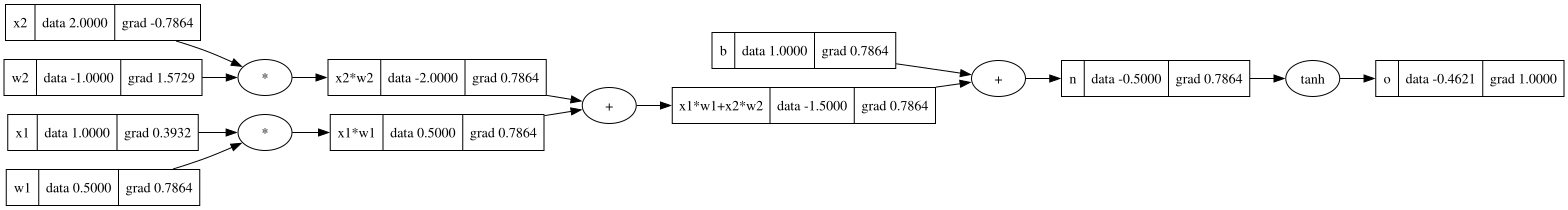

In [37]:
#değiştirmeden önce
x1 = Value(1.0 , label = 'x1')
x2 = Value(2.0, label = 'x2')

w1 = Value(0.5, label = 'w1')
w2 = Value(-1.0 , label = 'w2')

b = Value(1.0 , label  = 'b' ) 

x1w1 = x1*w1 ;  x1w1.label = 'x1*w1'
x2w2 = x2*w2 ; x2w2.label  ='x2*w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1*w1+x2*w2'

n = x1w1x2w2 + b ; n.label = 'n'

o = n.tanh(); o.label = 'o' 
o.backward()
draw_dot(o) 

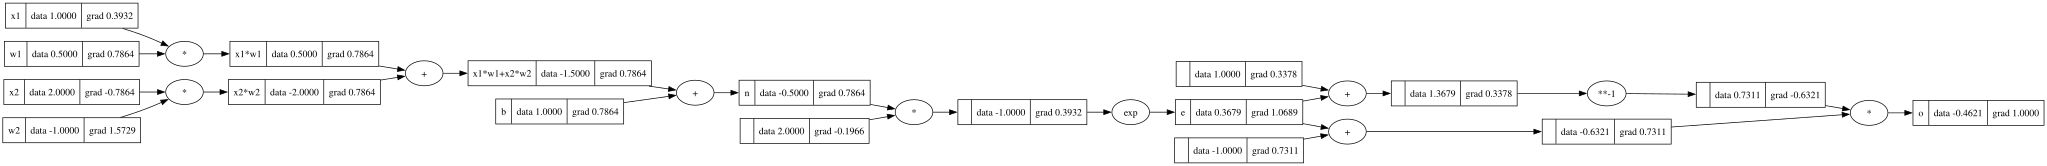

In [38]:
x1 = Value(1.0 , label = 'x1')
x2 = Value(2.0, label = 'x2')

w1 = Value(0.5, label = 'w1')
w2 = Value(-1.0 , label = 'w2')

b = Value(1.0 , label  = 'b' ) 

x1w1 = x1*w1 ;  x1w1.label = 'x1*w1'
x2w2 = x2*w2 ; x2w2.label  ='x2*w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1*w1+x2*w2'

n = x1w1x2w2 + b ; n.label = 'n'

e = (2 * n).exp() ; e.label = 'e'
o = (e - 1) / (e + 1) ; o.label = 'o'

o.backward()
draw_dot(o) 

In [39]:
x1 = 1.0
w1 = 0.5
x2 = 2.0
w2 = -1.0
b = 1.0

x1w1 = x1 * w1
x2w2 = x2 * w2
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b
e = math.exp(2*n)
o = (e - 1) / (e + 1)

h = 0.0001

L1 = o

degerler = {'x1': 1.0, 'x2': 2.0, 'w1': 0.5, 'w2': -1.0, 'b': 1.0}


for isim in degerler:
    x1 = 1.0; w1 = 0.5; x2 = 2.0; w2 = -1.0; b = 1.0
    if isim == 'x1': x1 = x1 + h
    if isim == 'x2': x2 = x2 + h
    if isim == 'w1': w1 = w1 + h
    if isim == 'w2': w2 = w2 + h
    if isim == 'b':  b  = b + h

    x1w1 = x1 * w1
    x2w2 = x2 * w2
    x1w1x2w2 = x1w1 + x2w2
    n = x1w1x2w2 + b
    e = math.exp(2 * n)
    o = (e - 1) / (e + 1)

    L2 = o
    grad = (L2 - L1) / h
    print(f"{isim}  data={degerler[isim]:.4f}  grad={grad:.4f}")

# x1w1 
x2w2 = 2.0 * -1.0
b = 1.0
x1w1 = 0.5 + h
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b
e = math.exp(2 * n)
o = (e - 1) / (e + 1)
L2 = o
grad_x1w1 = (L2 - L1) / h
print(f"x1w1  data=0.5000  grad={grad_x1w1:.4f}")

# x2w2
x1w1 = 1.0 * 0.5
b = 1.0
x2w2 = -2.0 + h
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b
e = math.exp(2 * n)
o = (e - 1) / (e + 1)
L2 = o
grad_x2w2 = (L2 - L1) / h
print(f"x2w2  data=-2.0000  grad={grad_x2w2:.4f}")

# x1w1x2w2
b = 1.0
x1w1x2w2 = -1.5 + h
n = x1w1x2w2 + b
e = math.exp(2 * n)
o = (e - 1) / (e + 1)
L2 = o
grad_x1w1x2w2 = (L2 - L1) / h
print(f"x1w1x2w2  data=-1.5000  grad={grad_x1w1x2w2:.4f}")

# n
n = -0.5 + h
e = math.exp(2 * n)
o = (e - 1) / (e + 1)
L2 = o
grad_n = (L2 - L1) / h
print(f"n  data=-0.5000  grad={grad_n:.4f}")

# e 
e = 0.36787944117144233 + h
o = (e - 1) / (e + 1)
L2 = o
grad_e = (L2 - L1) / h
print(f"e  data=0.3679  grad={grad_e:.4f}")

# o 
print("o  data=-0.4621  grad=1.0")



x1  data=1.0000  grad=0.3932
x2  data=2.0000  grad=-0.7864
w1  data=0.5000  grad=0.7865
w2  data=-1.0000  grad=1.5730
b  data=1.0000  grad=0.7865
x1w1  data=0.5000  grad=0.7865
x2w2  data=-2.0000  grad=0.7865
x1w1x2w2  data=-1.5000  grad=0.7865
n  data=-0.5000  grad=0.7865
e  data=0.3679  grad=1.0688
o  data=-0.4621  grad=1.0


In [ ]:
import torch

x1 = torch.Tensor([1.0]).double()                  ; x1.requires_grad = True
x2 = torch.Tensor([2.0]).double()                  ; x2.requires_grad = True
w1 = torch.Tensor([0.5]).double()                  ; w1.requires_grad = True
w2 = torch.Tensor([-1.0]).double()                 ; w2.requires_grad = True
b  = torch.Tensor([1.0]).double()                  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x1', x1.grad.item())
print('x2', x2.grad.item())
print('w1', w1.grad.item())
print('w2', w2.grad.item())
print('b', b.grad.item())
# üçünün de gradyanlarının eşitliği doğrulandı.

-0.46211715726000974
---
x1 0.3932238664829637
x2 -0.7864477329659274
w1 0.7864477329659274
w2 1.5728954659318548
b 0.7864477329659274
